In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#Load Data



In [11]:
df = pd.read_excel('Energy_efficiency.xlsx')

# EDA

In [12]:
#View Data

In [14]:
df.shape

(768, 10)

In [15]:
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
 8   Y1      768 non-null    float64
 9   Y2      768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [17]:
df.isnull().sum()

X1    0
X2    0
X3    0
X4    0
X5    0
X6    0
X7    0
X8    0
Y1    0
Y2    0
dtype: int64

#Stats analysis

In [19]:
df.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307195,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090204,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


#Visualization

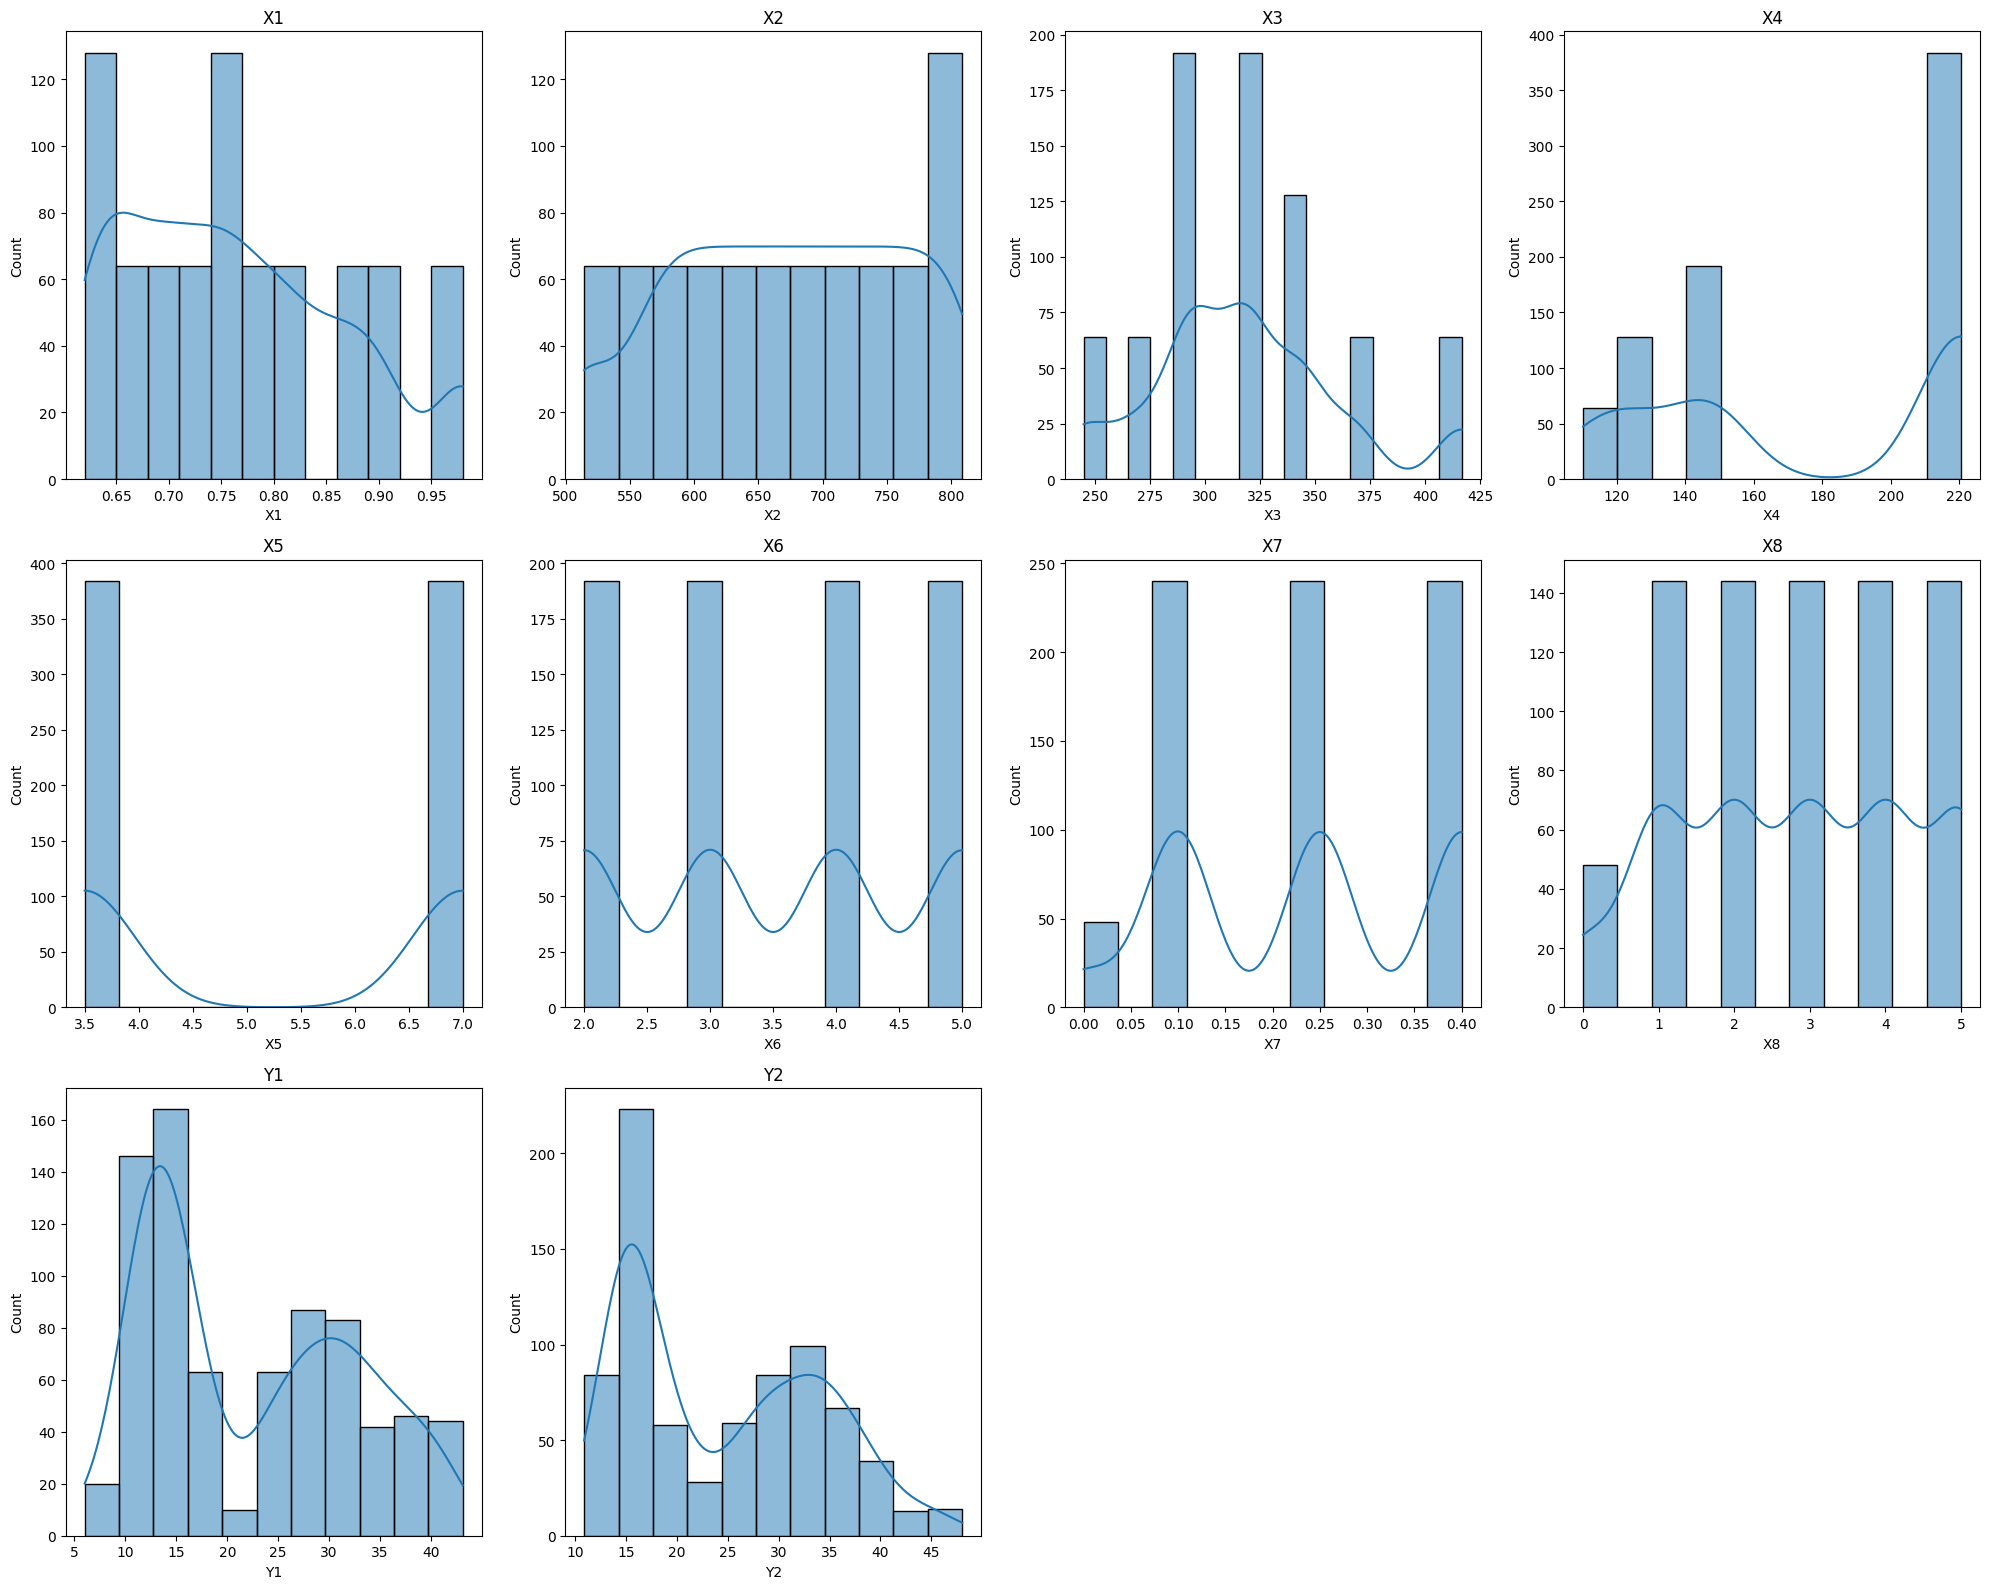

In [20]:
#Histogram for numerical distribution
plt.figure(figsize=(20,16))

for i, col in enumerate(df.columns):
    plt.subplot(3, 4, i+1)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

#Box plot for outliers

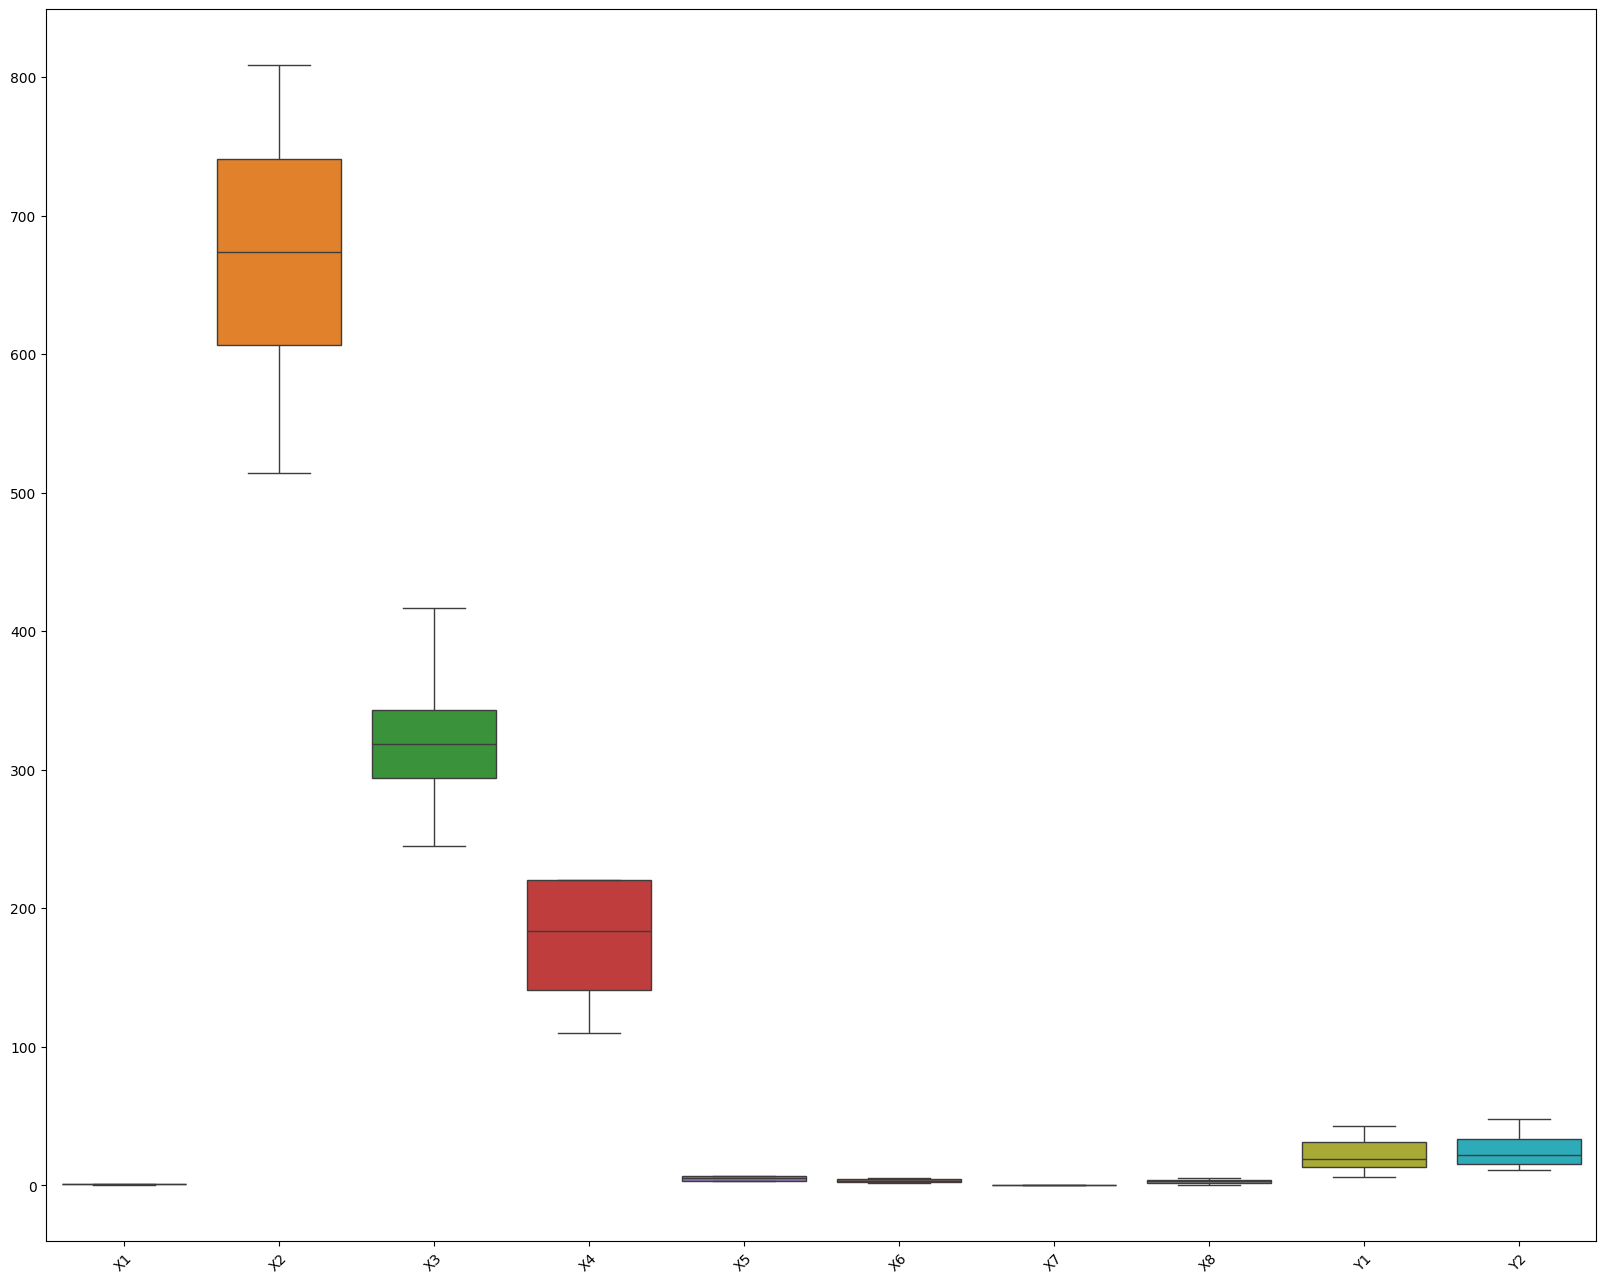

In [21]:
plt.figure(figsize=(20,16))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

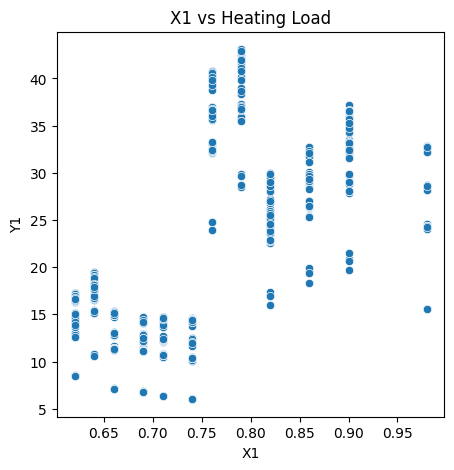

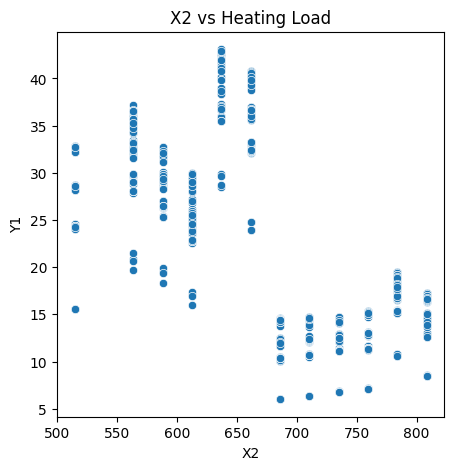

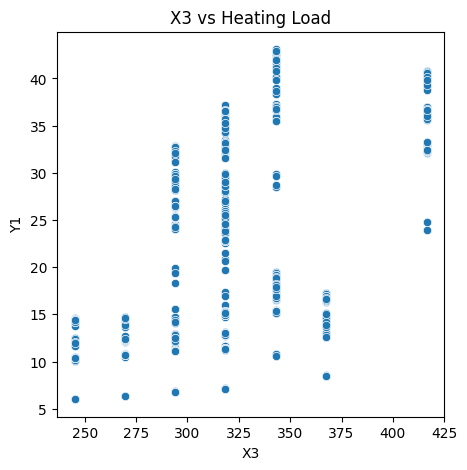

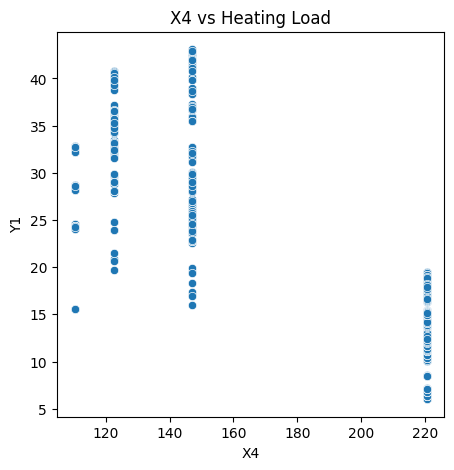

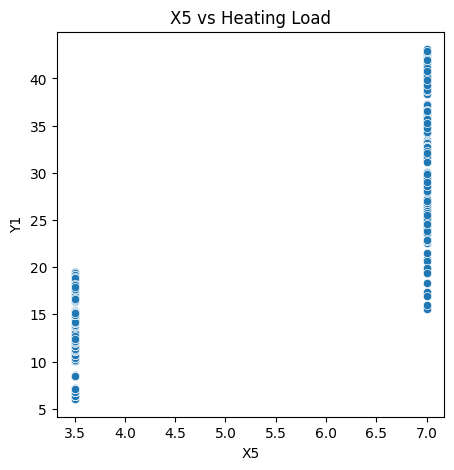

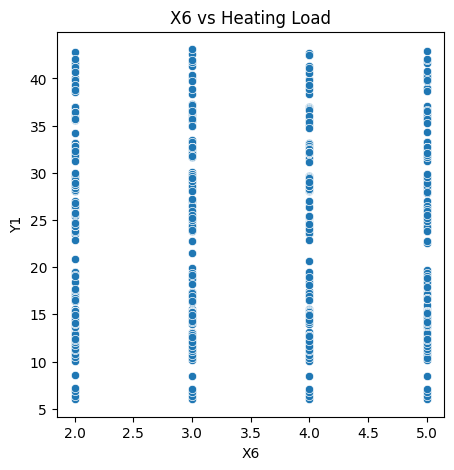

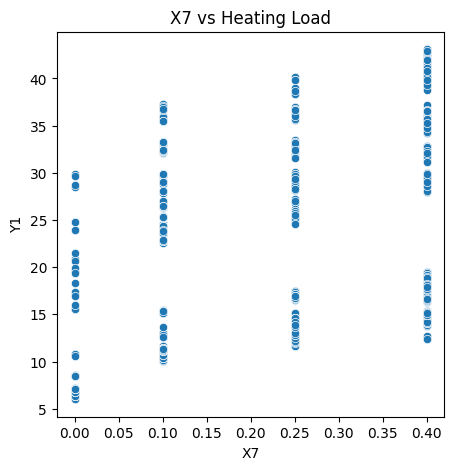

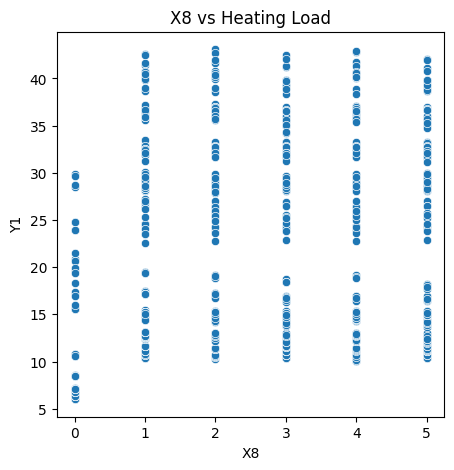

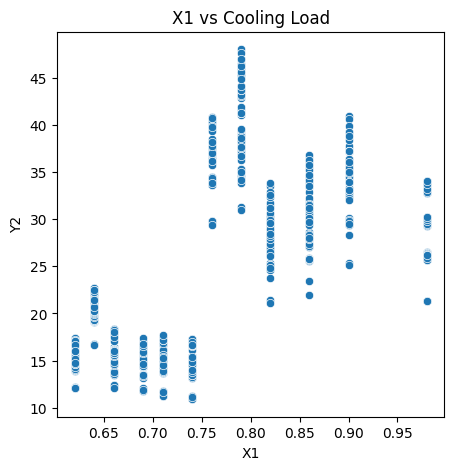

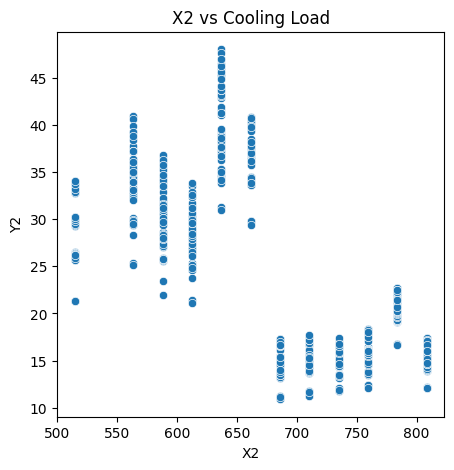

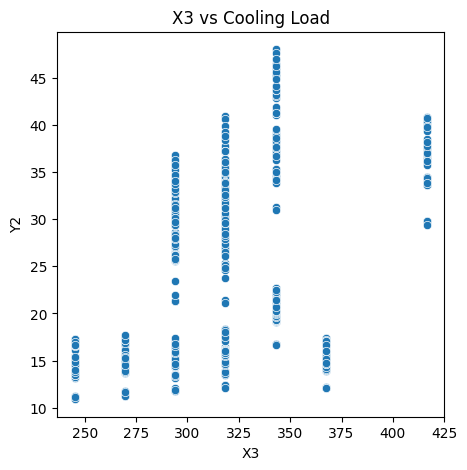

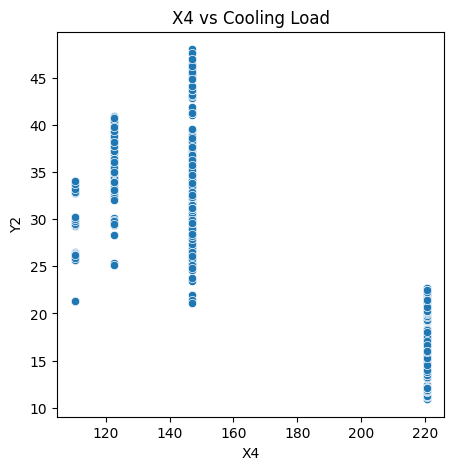

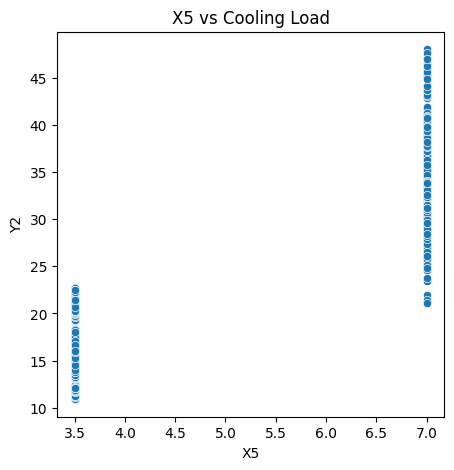

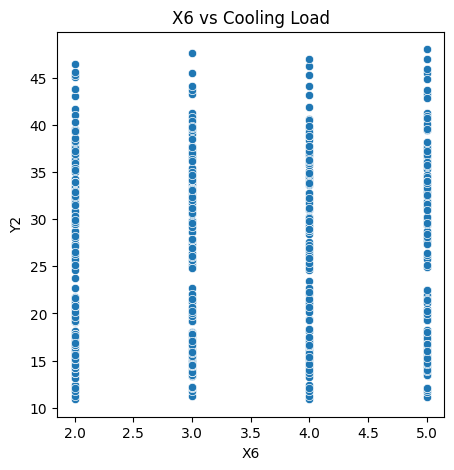

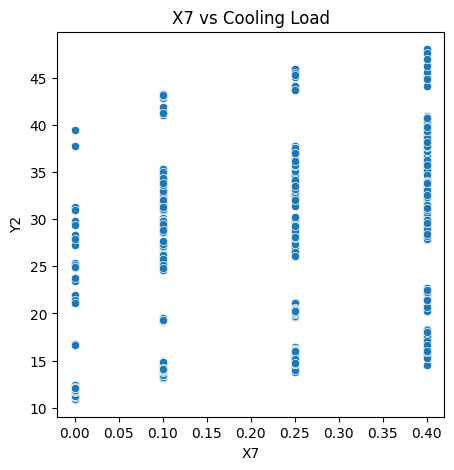

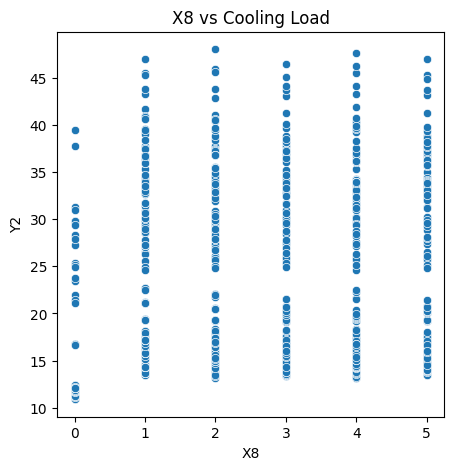

In [26]:
# Scatter plot
features = df.drop(columns=['Y1', 'Y2'])

for col in features.columns:
    plt.figure(figsize=(5,5))
    sns.scatterplot(x=df[col], y=df['Y1'])
    plt.title(f'{col} vs Heating Load')
    plt.show()
#for Y2 as well
for col in features.columns:
    plt.figure(figsize=(5,5))
    sns.scatterplot(x=df[col], y=df['Y2'])
    plt.title(f'{col} vs Cooling Load')
    plt.show()

#Features have different distributions and very different scales.
#Several features take discrete/fixed values there are not continuous values like X3, X5 and X7 have discrete values. 
#There are no obvious major outliers from the combined boxplot the boxplots of some var visually squashed near the bottom beacause of scales are massively different.
#The scatter plot suggests relationships with Heating Load and Cooling Load but they are not perfectly linear.

# Data Cleaning

In [28]:
df.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307195,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090204,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


In [36]:
#Handel missing values but there were none, now we will check for duplication
df.duplicated().sum()

#There were no wrong data types and inconsistent categories
#From boxplot we can see no outliers as well

np.int64(0)

#Fix logic and domain errors

In [33]:
#Unique values for discrete columns
for col in ['X3','X4','X5', 'X6', 'X7', 'X8']:
    print(col, df[col].unique())

X3 [294.  318.5 343.  416.5 245.  269.5 367.5]
X4 [110.25 122.5  147.   220.5 ]
X5 [7.  3.5]
X6 [2 3 4 5]
X7 [0.   0.1  0.25 0.4 ]
X8 [0 1 2 3 4 5]


In [37]:
#Few unique values ≠ categorical.
#Ask: Does the number represent a real quantity, or is it just a category code?

In [31]:
#Check if any non-positive if there?
print((df[['X2','X3','X4','X5','Y1','Y2']] <= 0).sum())

X2    0
X3    0
X4    0
X5    0
Y1    0
Y2    0
dtype: int64


# Pre-processing

In [41]:
# X6 (Orientation) and X8 (Glazing Area Distribution) contain numerical codes
# that represent categories, not actual numerical quantities, so we encode them.

df_original = pd.read_excel('Energy_efficiency.xlsx')

df_encoded = pd.get_dummies(
    df_original,
    columns=['X6', 'X8'],
    drop_first=True,
    dtype=int
)

In [39]:
df.head()

,X1,X2,X3,X4,X5,X7,Y1,Y2,X6_3,X6_4,X6_5,X8_1,X8_2,X8_3,X8_4,X8_5
0,0.98,514.5,294.0,110.25,7.0,0.0,15.55,21.33,0,0,0,0,0,0,0,0
1,0.98,514.5,294.0,110.25,7.0,0.0,15.55,21.33,1,0,0,0,0,0,0,0
2,0.98,514.5,294.0,110.25,7.0,0.0,15.55,21.33,0,1,0,0,0,0,0,0
3,0.98,514.5,294.0,110.25,7.0,0.0,15.55,21.33,0,0,1,0,0,0,0,0
4,0.90,563.5,318.5,122.50,7.0,0.0,20.84,28.28,0,0,0,0,0,0,0,0


In [42]:
print(df_original.shape)
print(df_encoded.shape)

(768, 10)
(768, 16)


# Feature Engineering

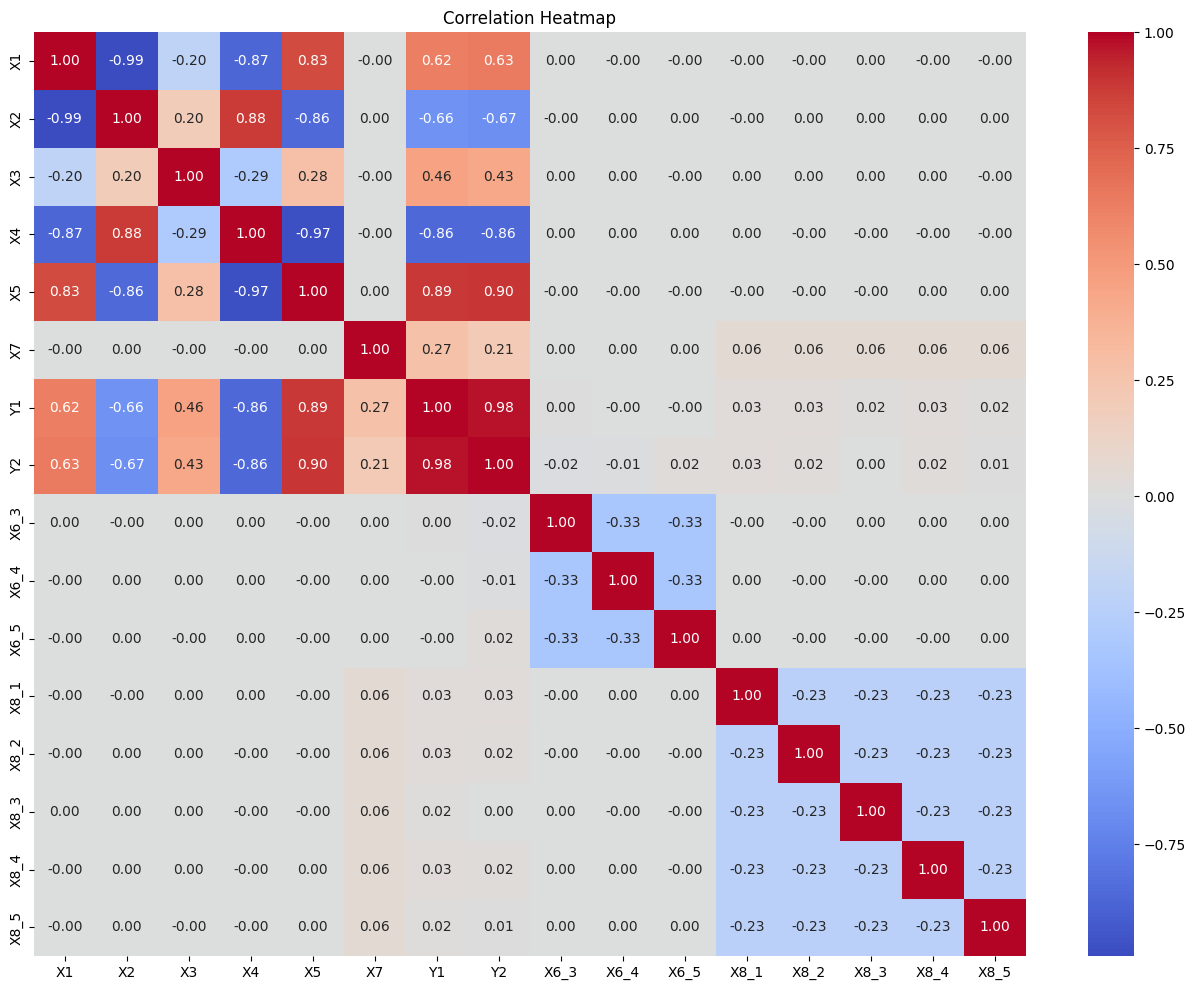

In [43]:
#checking correlation using pearson
correlation = df_encoded.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


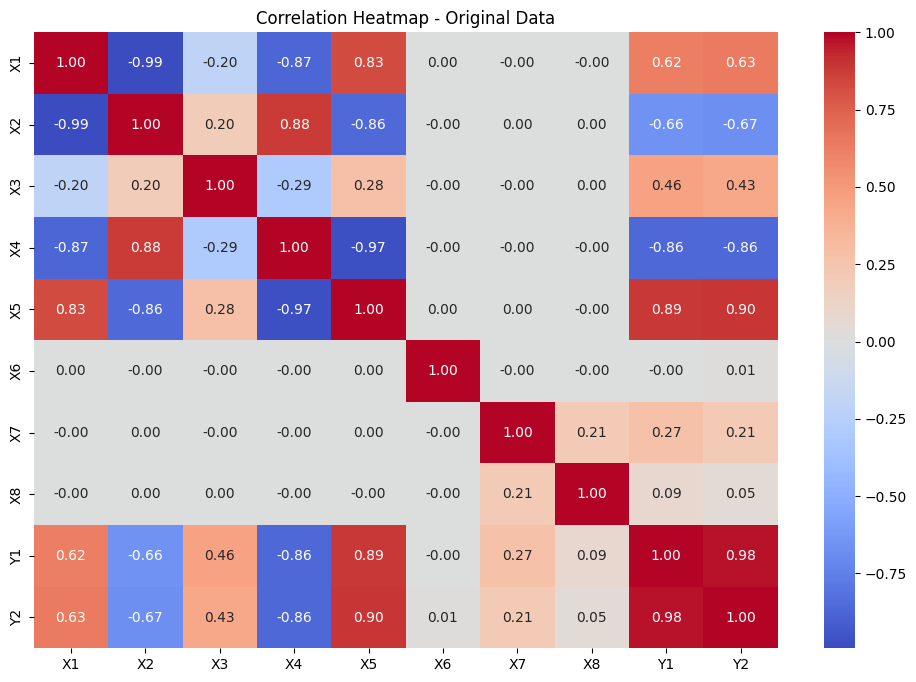

In [44]:
#Checking correlation before encoding
corr_original = df_original.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_original, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap - Original Data')
plt.show()

# Featuer Selection

In [45]:
# We will use original and encoded df for model predictiions and will compare which give best results.

# Split the data set

In [46]:
#for encoded dataframe
# Features and target
X = df_encoded.drop(columns=['Y1', 'Y2'])
y = df_encoded['Y1']

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardization

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Learn mean/std ONLY from training data
#fit = learn mean/std from training data
X_train_scaled = scaler.fit_transform(X_train) #The scaler learns:
#mean = 100
#std  = 20
#scaled = {x-100}/{20}

# Use the SAME learned mean/std on test data
X_test_scaled = scaler.transform(X_test) #transform = ONLY apply the existing rule. It learns nothing from test data. 

# Model A :  Multiple Linear Regression

In [48]:
model_A = LinearRegression()

model_A.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#Make predictions

In [49]:
y_pred_A = model_A.predict(X_test_scaled)

# Evaluate

In [50]:
r2_A = r2_score(y_test, y_pred_A)

print("R² Score:", r2_A)

R² Score: 0.9208501870029356


In [51]:
n = X_test_scaled.shape[0]   # number of test samples
p = X_test_scaled.shape[1]   # number of features

adjusted_r2_A = 1 - ((1 - r2_A) * (n - 1) / (n - p - 1))

print("Adjusted R²:", adjusted_r2_A)

Adjusted R²: 0.9128782633917205


In [52]:
mse_A = mean_squared_error(y_test, y_pred_A)
rmse_A = np.sqrt(mse_A)
mae_A = mean_absolute_error(y_test, y_pred_A)


print("MAE:", mae_A)
print("MSE:", mse_A)
print("RMSE:", rmse_A)


MAE: 2.0590362333385634
MSE: 8.249975702890719
RMSE: 2.87227709368207


# Create Model B features

In [53]:
# Model B: remove weak X6 and X8 encoded features
X_B = df_encoded.drop(
    columns=['Y1', 'Y2', 'X6_3', 'X6_4', 'X6_5',
             'X8_1', 'X8_2', 'X8_3', 'X8_4', 'X8_5']
)

y_B = df_encoded['Y1']

In [54]:
#Spilt 
X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_B, y_B, test_size=0.2, random_state=42
)

In [55]:
#Standardize
scaler_B = StandardScaler()

X_train_B_scaled = scaler_B.fit_transform(X_train_B)
X_test_B_scaled = scaler_B.transform(X_test_B)

In [56]:
#Train Model
model_B = LinearRegression()

model_B.fit(X_train_B_scaled, y_train_B)

y_pred_B = model_B.predict(X_test_B_scaled)

In [58]:
# Evaluation metrics for Model B

r2_B = r2_score(y_test_B, y_pred_B)

n = X_test_B_scaled.shape[0]
p = X_test_B_scaled.shape[1]

adjusted_r2_B = 1 - ((1 - r2_B) * (n - 1) / (n - p - 1))

mae_B = mean_absolute_error(y_test_B, y_pred_B)
mse_B = mean_squared_error(y_test_B, y_pred_B)
rmse_B = np.sqrt(mse_B)

print("R² Score:", r2_B)
print("Adjusted R²:", adjusted_r2_B)
print("MAE:", mae_B)
print("MSE:", mse_B)
print("RMSE:", rmse_B)

R² Score: 0.911563933140692
Adjusted R²: 0.9079542977586794
MAE: 2.163635818301817
MSE: 9.217904316155126
RMSE: 3.0361001821671048
